In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import importlib
import functions as f
from scintkit.preprocessing.format import temp_formating
from scintkit.services.phase_detrend import detect_sampling_rate
import time
import CONFIG as cf

importlib.reload(f)
importlib.reload(cf)
start = time.time()

#prepping test example dfs


# import pqs
dfa = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359072.7500W_72126.9375S_v325_lvl0.pq')
dfb = pd.read_parquet(r'C:\Users\irees\Downloads\Summer_learning\research26\Brazil_22_lvl0\scintpi3_20221004_2000_359060.7812W_72122.4141S_v325_lvl0.pq')

print(f"time to read files: {time.time() - start:.3f} seconds")

# filter dfs to contain certain elevation
dfa = dfa[dfa['elev'] > 20].copy()
dfb = dfb[dfb['elev'] > 20].copy()
dfa = temp_formating(dfa)
dfb = temp_formating(dfb)

samp_ra = detect_sampling_rate(dfa)

dt = 1 / samp_ra

display(dfa)

# merge 2 receiver dfs
merged = dfa.merge(dfb, on=["datetime", "svid", "cons"], suffixes=("_A", "_B"))
merged['snr_diff'] = abs(merged['snr1_A'] - merged['snr1_B'])

merged = temp_formating(merged)


print(f"time to create new time: {time.time() - start:.3f} seconds")

thresh = cf.thresh  # threshold for s4 scintillation measurement


#### start cross corr file creation

rstart = time.time()

scint = []

sat_groups = merged.groupby(['svid', 'cons'])

for (svid, cons), sat_group in sat_groups:

    # group the data into different satellites
    sat_group = f.datetime_to_seconds(sat_group)

    min_groups = sat_group.groupby(sat_group['datetime'].dt.floor('min'))

    # with the chosen satellite for this iteration
    # find s4 and then determine scintillation
    for min, group in min_groups:
        
        group = f.handle_nan(group, 'drop')
        #add nan processing
        if len(group) < 10:
            continue

        sig_lina = f.db2lin(group['snr1_A'])
        s4a = np.std(sig_lina) / np.mean(sig_lina)

        sig_linb = f.db2lin(group['snr1_B'])
        s4b = np.std(sig_linb) / np.mean(sig_linb)

        if s4a > thresh or s4b > thresh:

            # check threshold of scintillation and compute correlation
            correlation, lag_b, cor_norm, lag_norm = f.cross_correlation(group["snr1_A"], group["snr1_B"])
            autoA_max, autoA_lagb, autoA_cor, autoA_lags = f.cross_correlation(group['snr1_A'], group['snr1_A'])
            autoB_max, autoB_lagb, autoB_cor, autoB_lags = f.cross_correlation(group['snr1_B'], group['snr1_B'])

            # dt = group['time_sec'].diff().median()
            time_delay = lag_b * dt

            scint.append({
                'minute': min,
                'prn' : group['prn_B'].iloc[0],
                's4A': s4a,
                's4B': s4b,
                

                #adding elev and azim
                'elev' : group['elev_A'].mean(),
                'azim' : group['azim_A'].mean(),
                
                #adding location, using the location at the start of each minute not the mean, can be changed
                'rAloc' : (group['lat_A'].iloc[0]/10000, group['lon_A'].iloc[0]/10000, group['hei_A'].mean()/1000),
                'rBloc' : (group['lat_B'].iloc[0]/10000, group['lon_B'].iloc[0]/10000, group['hei_B'].mean()/1000),

                'auto_cor_A' : autoA_cor,
                'auto_cor_Amax' : autoA_max,
                'auto_cor_B' : autoB_cor,
                'auto_cor_Bmax' : autoB_max,


                'corr_norm': cor_norm,
                'lag_norm': lag_norm,
                'max_corr': correlation,
                'best_lag': lag_b,
                'time_delay': time_delay
            })

# create dataframe storing all scintillation events
cross_cor = pd.DataFrame(scint)
display(cross_cor)

print(f"Processed {len(cross_cor)} scintillation events")
print(f"Runtime: {time.time() - rstart:.3f} seconds")

display(cross_cor)
print(cross_cor['prn'].unique())


time to read files: 2.334 seconds


,index,leap,cons,svid,elev,azim,snr1,snr2,snr3,pst3,...,hei,datetime,minbin,prn,sig_1,sig_2,sig_3,freq_1,freq_2,freq_3
0,0,18,GPS,15,36,92,46.0,42.0,NaN,0,...,543.103027,2022-10-04 20:00:18.203125,2022-10-04 20:00:00,G15,GPS_L1CA,GPS_L2C,GPS_L5,1575.420,1227.60,1176.450
1,2,18,GPS,12,29,23,43.0,39.0,NaN,0,...,543.103027,2022-10-04 20:00:18.203125,2022-10-04 20:00:00,G12,GPS_L1CA,GPS_L2C,GPS_L5,1575.420,1227.60,1176.450
2,3,18,GPS,29,45,152,46.0,42.0,NaN,0,...,543.103027,2022-10-04 20:00:18.203125,2022-10-04 20:00:00,G29,GPS_L1CA,GPS_L2C,GPS_L5,1575.420,1227.60,1176.450
3,4,18,GPS,18,33,207,43.0,43.0,NaN,0,...,543.103027,2022-10-04 20:00:18.203125,2022-10-04 20:00:00,G18,GPS_L1CA,GPS_L2C,GPS_L5,1575.420,1227.60,1176.450
4,6,18,BDS,32,26,136,43.0,NaN,NaN,0,...,543.103027,2022-10-04 20:00:18.203125,2022-10-04 20:00:00,C32,BDS_B1I,BDS_B2I,BDS_B3I,1561.098,1207.14,1268.520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6742396,10588362,18,GLO,7,49,249,50.0,49.0,NaN,0,...,543.125000,2022-10-04 23:59:30.250000,2022-10-04 23:59:00,R07,GLO_L1CA,GLO_L2C,GLO_L3,1602.000,1246.00,1202.025
6742397,10588364,18,SBS,136,42,82,45.0,NaN,NaN,0,...,543.125000,2022-10-04 23:59:30.250000,2022-10-04 23:59:00,S136,NaN,NaN,None,NaN,NaN,NaN
6742398,10588366,18,GAL,5,48,159,44.0,51.0,NaN,0,...,543.125000,2022-10-04 23:59:30.250000,2022-10-04 23:59:00,E05,GAL_L1BC,GAL_E5b,GAL_E5b,1575.420,1207.14,1207.140
6742399,10588367,18,GAL,34,46,175,48.0,56.0,NaN,0,...,543.125000,2022-10-04 23:59:30.250000,2022-10-04 23:59:00,E34,GAL_L1BC,GAL_E5b,GAL_E5b,1575.420,1207.14,1207.140


time to create new time: 49.337 seconds


,minute,prn,s4A,s4B,elev,azim,rAloc,rBloc,auto_cor_A,auto_cor_Amax,auto_cor_B,auto_cor_Bmax,corr_norm,lag_norm,max_corr,best_lag,time_delay
0,2022-10-04 22:22:00,E02,0.246203,0.248260,32.00000,306.547917,"(-7.212652, -35.9073, 0.5425475)","(-7.2121882, -35.90611, 0.55649865)","[7.453151618398635e-05, 0.000489778534923339, ...",1.0,"[0.0007473841554558992, 0.0014947683109117983,...",1.0,"[0.00023601625850355374, 0.0004720325170071075...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,-6,-0.30
1,2022-10-04 22:23:00,E02,0.282083,0.258300,32.00000,307.000000,"(-7.212652, -35.907295, 0.542493)","(-7.2121882, -35.906105, 0.5563686)","[5.653192470854709e-08, 1.1306384941709418e-07...",1.0,"[-0.0002862061228668591, -0.000572412245733718...",1.0,"[9.023856161992943e-07, 1.8047712323985886e-06...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,-6,-0.30
2,2022-10-04 22:24:00,E02,0.339789,0.356450,31.48847,307.511530,"(-7.212652, -35.907295, 0.54223895)","(-7.2121873, -35.906105, 0.55611974)","[1.4328560169239606e-05, 2.8657120338479213e-0...",1.0,"[-6.744767325199305e-05, -0.000134895346503986...",1.0,"[1.4377542661671244e-06, 2.875508532334249e-06...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,-6,-0.30
3,2022-10-04 22:25:00,E02,0.314274,0.316135,31.00000,308.000000,"(-7.212652, -35.907295, 0.5419835)","(-7.2121873, -35.906105, 0.55578876)","[-0.00020526582306656593, -0.00030202107887327...",1.0,"[-0.00026176338703215663, -0.00052352677406431...",1.0,"[0.001075369544539739, 0.0015822617968117743, ...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,-6,-0.30
4,2022-10-04 22:26:00,E02,0.325862,0.345028,31.00000,308.481250,"(-7.212654, -35.907295, 0.5417687)","(-7.2121882, -35.906105, 0.5553776)","[-0.00012863502852089365, 0.000664294326391474...",1.0,"[-0.0003301509261376589, -0.000660301852275317...",1.0,"[-0.0002447835548298513, 0.001264106118972056,...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,-7,-0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,2022-10-04 23:37:00,S136,0.340081,0.332755,42.00000,82.000000,"(-7.2126813, -35.907364, 0.53728354)","(-7.2122126, -35.906174, 0.55261135)","[-0.0015268451462488895, -0.003053690292497779...",1.0,"[-8.878722740604429e-05, -0.000177574454812088...",1.0,"[-0.0004538780324835893, -0.000907756064967178...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,-18,-0.90
1531,2022-10-04 23:38:00,S136,0.274253,0.311478,42.00000,82.000000,"(-7.2126837, -35.907364, 0.5371062)","(-7.2122173, -35.906174, 0.5526083)","[-0.0020429527221507743, -0.004085905444301549...",1.0,"[0.0005966432587921004, 0.0011932865175842008,...",1.0,"[0.0009568130425962295, 0.001913626085192459, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,-18,-0.90
1532,2022-10-04 23:39:00,S136,0.258914,0.263936,42.00000,82.000000,"(-7.2126837, -35.907364, 0.53767467)","(-7.2122197, -35.906174, 0.55342394)","[0.0010492216341598936, 0.002098443268319787, ...",1.0,"[-0.0007197609850313849, -0.001439521970062769...",1.0,"[0.0018620475860781568, 0.0037240951721563137,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,-16,-0.80
1533,2022-10-04 23:40:00,S136,0.179114,0.212937,42.00000,82.000000,"(-7.2126865, -35.90736, 0.5384905)","(-7.2122235, -35.906166, 0.55444056)","[-0.0017284283257443301, -0.001142642993588310...",1.0,"[-0.001322385975152172, -0.002644771950304344,...",1.0,"[-0.0012822319439833017, -0.000847667979704448...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,-23,-1.15


Processed 1535 scintillation events
Runtime: 19.053 seconds


,minute,prn,s4A,s4B,elev,azim,rAloc,rBloc,auto_cor_A,auto_cor_Amax,auto_cor_B,auto_cor_Bmax,corr_norm,lag_norm,max_corr,best_lag,time_delay
0,2022-10-04 22:22:00,E02,0.246203,0.248260,32.00000,306.547917,"(-7.212652, -35.9073, 0.5425475)","(-7.2121882, -35.90611, 0.55649865)","[7.453151618398635e-05, 0.000489778534923339, ...",1.0,"[0.0007473841554558992, 0.0014947683109117983,...",1.0,"[0.00023601625850355374, 0.0004720325170071075...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,-6,-0.30
1,2022-10-04 22:23:00,E02,0.282083,0.258300,32.00000,307.000000,"(-7.212652, -35.907295, 0.542493)","(-7.2121882, -35.906105, 0.5563686)","[5.653192470854709e-08, 1.1306384941709418e-07...",1.0,"[-0.0002862061228668591, -0.000572412245733718...",1.0,"[9.023856161992943e-07, 1.8047712323985886e-06...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,-6,-0.30
2,2022-10-04 22:24:00,E02,0.339789,0.356450,31.48847,307.511530,"(-7.212652, -35.907295, 0.54223895)","(-7.2121873, -35.906105, 0.55611974)","[1.4328560169239606e-05, 2.8657120338479213e-0...",1.0,"[-6.744767325199305e-05, -0.000134895346503986...",1.0,"[1.4377542661671244e-06, 2.875508532334249e-06...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,-6,-0.30
3,2022-10-04 22:25:00,E02,0.314274,0.316135,31.00000,308.000000,"(-7.212652, -35.907295, 0.5419835)","(-7.2121873, -35.906105, 0.55578876)","[-0.00020526582306656593, -0.00030202107887327...",1.0,"[-0.00026176338703215663, -0.00052352677406431...",1.0,"[0.001075369544539739, 0.0015822617968117743, ...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,-6,-0.30
4,2022-10-04 22:26:00,E02,0.325862,0.345028,31.00000,308.481250,"(-7.212654, -35.907295, 0.5417687)","(-7.2121882, -35.906105, 0.5553776)","[-0.00012863502852089365, 0.000664294326391474...",1.0,"[-0.0003301509261376589, -0.000660301852275317...",1.0,"[-0.0002447835548298513, 0.001264106118972056,...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,-7,-0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,2022-10-04 23:37:00,S136,0.340081,0.332755,42.00000,82.000000,"(-7.2126813, -35.907364, 0.53728354)","(-7.2122126, -35.906174, 0.55261135)","[-0.0015268451462488895, -0.003053690292497779...",1.0,"[-8.878722740604429e-05, -0.000177574454812088...",1.0,"[-0.0004538780324835893, -0.000907756064967178...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,-18,-0.90
1531,2022-10-04 23:38:00,S136,0.274253,0.311478,42.00000,82.000000,"(-7.2126837, -35.907364, 0.5371062)","(-7.2122173, -35.906174, 0.5526083)","[-0.0020429527221507743, -0.004085905444301549...",1.0,"[0.0005966432587921004, 0.0011932865175842008,...",1.0,"[0.0009568130425962295, 0.001913626085192459, ...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,-18,-0.90
1532,2022-10-04 23:39:00,S136,0.258914,0.263936,42.00000,82.000000,"(-7.2126837, -35.907364, 0.53767467)","(-7.2122197, -35.906174, 0.55342394)","[0.0010492216341598936, 0.002098443268319787, ...",1.0,"[-0.0007197609850313849, -0.001439521970062769...",1.0,"[0.0018620475860781568, 0.0037240951721563137,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,-16,-0.80
1533,2022-10-04 23:40:00,S136,0.179114,0.212937,42.00000,82.000000,"(-7.2126865, -35.90736, 0.5384905)","(-7.2122235, -35.906166, 0.55444056)","[-0.0017284283257443301, -0.001142642993588310...",1.0,"[-0.001322385975152172, -0.002644771950304344,...",1.0,"[-0.0012822319439833017, -0.000847667979704448...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,-23,-1.15


['E02' 'E03' 'R04' 'E05' 'R05' 'R06' 'R07' 'R08' 'E09' 'R09' 'G10' 'G12'
 'E14' 'G15' 'G16' 'G18' 'C19' 'R19' 'C20' 'R20' 'R21' 'C22' 'G22' 'G23'
 'E24' 'E25' 'G25' 'G26' 'G27' 'C29' 'G29' 'C30' 'G31' 'C32' 'G32' 'E34'
 'C35' 'C36' 'S136']


In [2]:
cross_cor['distance (km)'] = cross_cor.apply(lambda row: f.calc_dist(row['rAloc'], row['rBloc']), axis = 1)
cross_cor['velocity (km/s)'] = cross_cor['distance (km)']/cross_cor['time_delay']
sat = cross_cor[cross_cor['prn'] == 'G10'] 
display(sat)

,minute,prn,s4A,s4B,elev,azim,rAloc,rBloc,auto_cor_A,auto_cor_Amax,auto_cor_B,auto_cor_Bmax,corr_norm,lag_norm,max_corr,best_lag,time_delay,distance (km),velocity (km/s)
293,2022-10-04 20:19:00,G10,0.201961,0.070515,40.000000,309.000000,"(-7.2126865, -35.907265, 0.54672724)","(-7.212241, -35.906075, 0.5615411)","[0.0006499227751697904, 0.0012998455503395808,...",1.0,"[0.00020346779900920717, 0.0004069355980184143...",1.0,"[9.521972207072011e-05, 0.00019043944414144022...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.271832,-89,-4.45,0.140938,-0.031672
294,2022-10-04 20:51:00,G10,0.100693,0.215122,50.000000,290.000000,"(-7.2126875, -35.90726, 0.5404531)","(-7.212226, -35.906067, 0.5568761)","[0.004813218390804566, 0.009626436781609132, 0...",1.0,"[7.443687158042958e-05, 0.00014887374316085915...",1.0,"[-0.0005985657184009801, -0.001197131436801960...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.349516,-20,-1.00,0.142457,-0.142457
295,2022-10-04 22:53:00,G10,0.237948,0.218115,40.000000,198.000000,"(-7.212663, -35.907295, 0.5354846)","(-7.212177, -35.906113, 0.54839563)","[-0.000689563238623071, -0.0016526722247990956...",1.0,"[-0.003274513772131908, -0.006549027544263816,...",1.0,"[-0.002420563703432957, -0.004841127406865914,...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.735514,-13,-0.65,0.141726,-0.218040
296,2022-10-04 22:54:00,G10,0.492914,0.469104,39.419444,197.419444,"(-7.2126665, -35.907295, 0.53490907)","(-7.2121773, -35.906116, 0.54801375)","[-0.001182138221148842, -0.001531458908807306,...",1.0,"[-0.0043406829015337385, -0.008681365803067477...",1.0,"[-0.0010476500922585296, -0.001357229669422987...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.881705,-21,-1.05,0.141507,-0.134768
297,2022-10-04 22:55:00,G10,1.040916,1.021276,39.000000,197.000000,"(-7.2126656, -35.907295, 0.5346412)","(-7.212177, -35.906116, 0.54756856)","[0.00033894813248366157, 0.0006167480175636056...",1.0,"[0.0013504667768690134, 0.0029747539083833908,...",1.0,"[0.0015202354591833593, 0.0027662114519141955,...","[-719, -718, -717, -716, -715, -714, -713, -71...",0.904379,-20,-1.00,0.141454,-0.141454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,2022-10-04 23:55:00,G10,0.515771,0.676954,27.419792,169.000000,"(-7.212689, -35.90734, 0.5431365)","(-7.212226, -35.906155, 0.55914867)","[0.001102941176470586, 0.002205882352941172, 0...",1.0,"[0.00022761029546493176, 0.0004552205909298635...",1.0,"[0.00011758100800402133, 0.0002351620160080426...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.747849,-67,-3.35,0.141434,-0.042219
358,2022-10-04 23:56:00,G10,0.908810,0.910103,27.000000,169.000000,"(-7.2126927, -35.90734, 0.5427405)","(-7.2122307, -35.90616, 0.5591218)","[-0.0007440978327096978, -0.001488195665419395...",1.0,"[7.454904538178217e-05, 0.00014909809076356435...",1.0,"[0.0010845395671622684, 0.0021690791343245367,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.673341,-70,-3.50,0.141059,-0.040302
359,2022-10-04 23:57:00,G10,1.019282,0.735396,27.000000,168.453125,"(-7.212695, -35.90734, 0.54295677)","(-7.2122307, -35.90616, 0.56004244)","[0.003581806257419988, 0.007163612514839976, 0...",1.0,"[-0.000977021118753717, -0.001954042237507434,...",1.0,"[0.00216081491716276, 0.00432162983432552, 0.0...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.359487,-73,-3.65,0.141246,-0.038698
360,2022-10-04 23:58:00,G10,1.262397,1.005542,27.000000,168.000000,"(-7.2126937, -35.90734, 0.54346997)","(-7.212229, -35.906155, 0.5603624)","[-0.0014370684287453677, -0.002874136857490735...",1.0,"[0.0008354514120699083, 0.0016709028241398167,...",1.0,"[0.0015371988875800776, 0.0030743977751601552,...","[-933, -932, -931, -930, -929, -928, -927, -92...",0.412348,-76,-3.80,0.141571,-0.037255


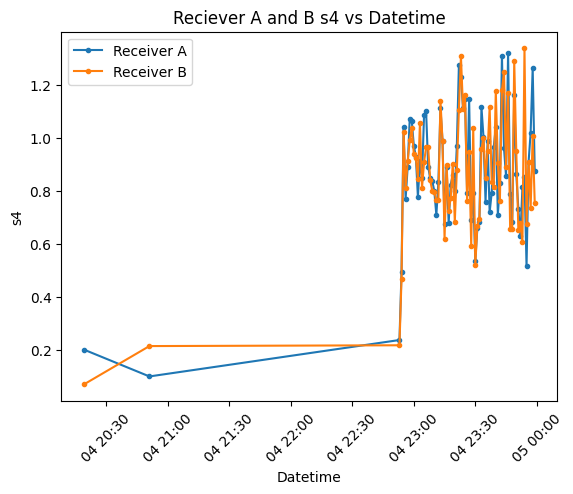

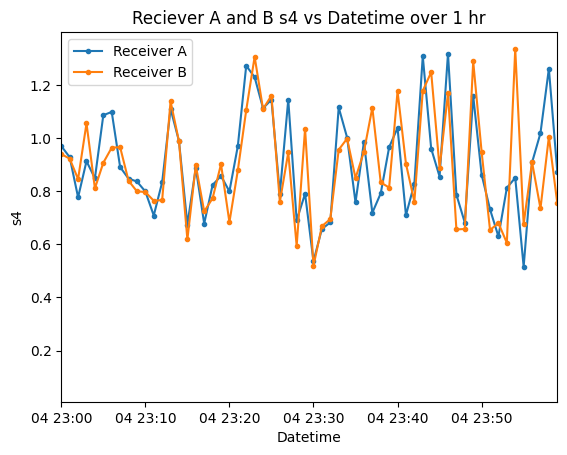

In [3]:


plt.plot(sat["minute"], sat["s4A"],'.-', label="Receiver A")
plt.plot(sat["minute"], sat["s4B"],'.-', label="Receiver B")
# plt.xlim(
#        pd.Timestamp("2022-10-04 23:00:00"),
#       pd.Timestamp("2022-10-04 23:01:00")
#     )
plt.legend()
plt.xlabel('Datetime')
plt.ylabel('s4')
plt.title('Reciever A and B s4 vs Datetime')
plt.xticks(rotation=45)
plt.show()

#graph showing scintiallltion at 23:00 to 23:30
plt.plot(sat["minute"], sat["s4A"],'.-', label="Receiver A")
plt.plot(sat["minute"], sat["s4B"],'.-', label="Receiver B")
plt.xlim(
       pd.Timestamp("2022-10-04 23:00:00"),
      pd.Timestamp("2022-10-04 23:59:00")
    )
plt.legend()
plt.xlabel('Datetime')
plt.ylabel('s4')
plt.title('Reciever A and B s4 vs Datetime over 1 hr')
plt.show()


minute                                           2022-10-04 23:31:00
prn                                                              G10
s4A                                                          0.65847
s4B                                                         0.668578
elev                                                            32.0
azim                                                      179.019792
rAloc                             (-7.212695, -35.907368, 0.5295303)
rBloc                            (-7.212225, -35.906174, 0.54520535)
auto_cor_A         [9.59770507731415e-05, 0.000191954101546283, 0...
auto_cor_Amax                                                    1.0
auto_cor_B         [-0.0010420652903519558, -0.001585186601283523...
auto_cor_Bmax                                                    1.0
corr_norm          [0.0004327917242666097, 0.0008655834485332194,...
lag_norm           [-959, -958, -957, -956, -955, -954, -953, -95...
max_corr                          

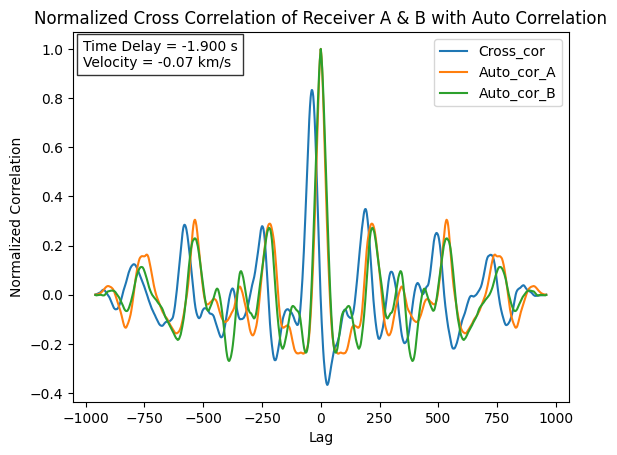

In [4]:
#choosing 1 event: 

event = sat.iloc[40]
display(event)

plt.plot(event['lag_norm'], event['corr_norm'], label = 'Cross_cor')
plt.plot(event['lag_norm'], event['auto_cor_A'], label = 'Auto_cor_A')
plt.plot(event['lag_norm'], event['auto_cor_B'], label = 'Auto_cor_B')

text = (f"Time Delay = {event['time_delay']:.3f} s\n" f"Velocity = {event['velocity (km/s)']:.2f} km/s")

plt.text(
    0.02, 0.98,
    text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.legend()
plt.xlabel('Lag')
plt.ylabel('Normalized Correlation')
plt.title('Normalized Cross Correlation of Receiver A & B with Auto Correlation')
plt.show()



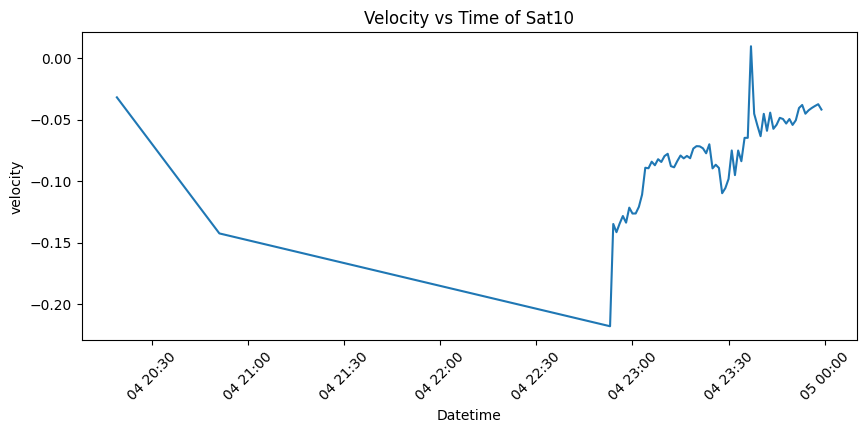

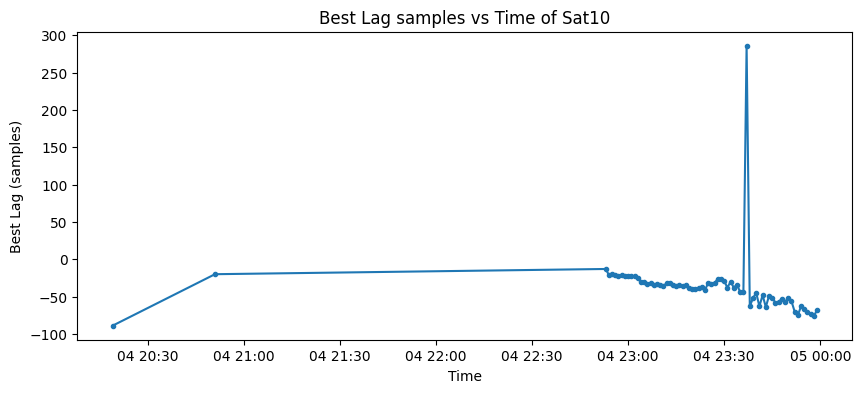

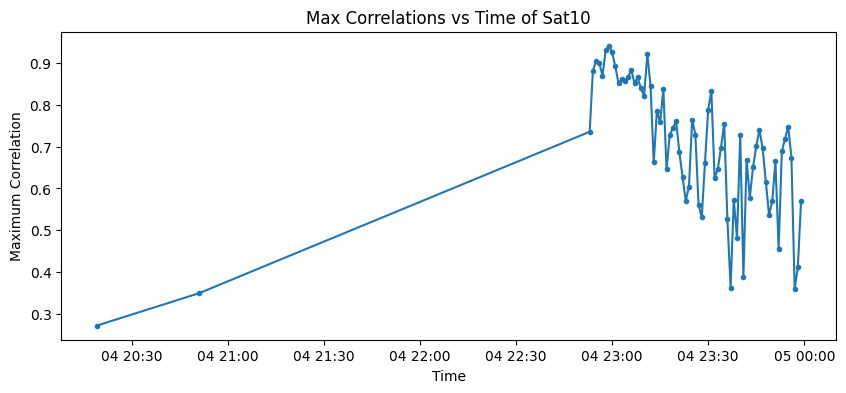

In [12]:
#plotting velocity estimates:
plt.figure(figsize=(10,4))
plt.plot(sat['minute'], sat['velocity (km/s)'])
plt.xlabel('Datetime')
plt.ylabel('velocity')
plt.title('Velocity vs Time of Sat10')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(sat['minute'], sat['best_lag'], '.-')
plt.xlabel("Time")
plt.ylabel("Best Lag (samples)")
plt.title('Best Lag samples vs Time of Sat10')

plt.show()

plt.figure(figsize=(10,4))
plt.plot(sat['minute'], sat['max_corr'], '.-')
plt.xlabel("Time")
plt.ylabel("Maximum Correlation")
plt.title('Max Correlations vs Time of Sat10')

plt.show()

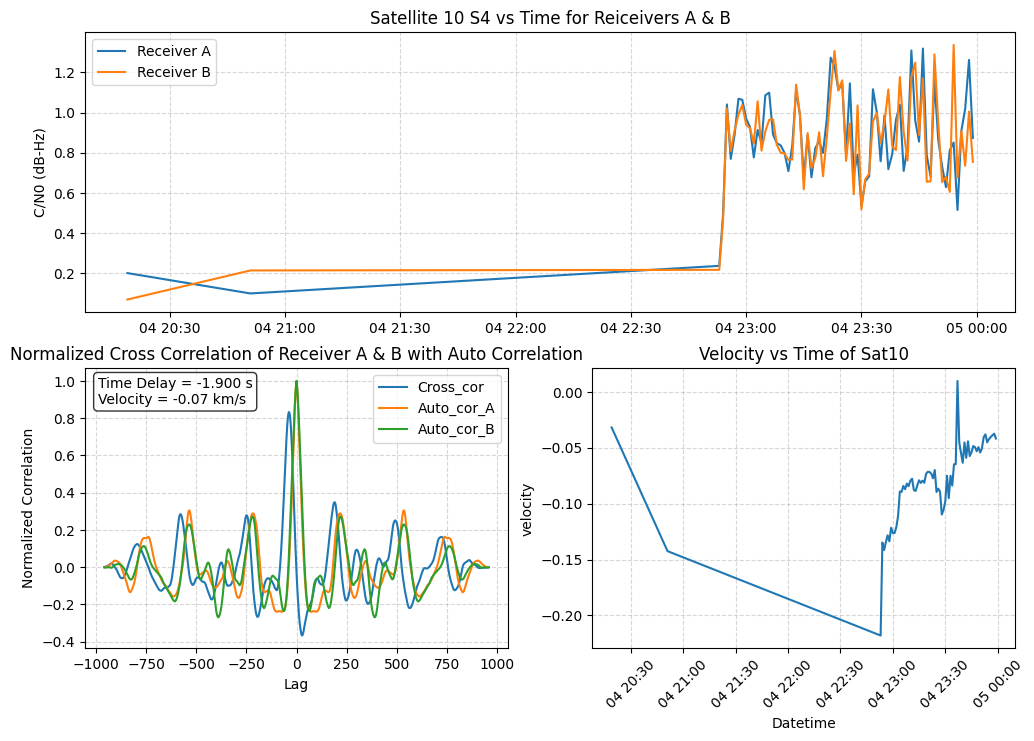

In [ ]:
#recreating isaac's graph


fig = plt.figure(figsize = (12, 8))
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0,:]) #top spanning all
ax2 = fig.add_subplot(gs[1, 0])   # bottom left
ax3 = fig.add_subplot(gs[1, 1])   # bottom right


ax1.plot(sat['minute'], sat['s4A'], label='Receiver A')
ax1.plot(sat['minute'], sat['s4B'], label='Receiver B')

ax1.set_ylabel("s4")
ax1.legend()
ax1.set_title('Satellite 10 S4 vs Time for Reiceivers A & B')

ax2.plot(event['lag_norm'], event['corr_norm'], label = 'Cross_cor')
ax2.plot(event['lag_norm'], event['auto_cor_A'], label = 'Auto_cor_A')
ax2.plot(event['lag_norm'], event['auto_cor_B'], label = 'Auto_cor_B')

text = (f"Time Delay = {event['time_delay']:.3f} s\n" f"Velocity = {event['velocity (km/s)']:.2f} km/s")
ax2.text(
    x=0.03,
    y=0.97,
    s=text,
    transform=ax2.transAxes,
    fontsize=10,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8)
)
ax2.legend()
ax2.set_xlabel('Lag')
ax2.set_ylabel('Normalized Correlation')
ax2.set_title('Normalized Cross Correlation of Receiver A & B with Auto Correlation')

ax3.plot(sat['minute'], sat['velocity (km/s)'])
ax3.set_xlabel('Datetime')
ax3.set_ylabel('velocity')
ax3.set_title('Velocity vs Time of Sat10')
ax3.tick_params(axis='x', labelrotation=45)



ax1.grid(True, linestyle='--', alpha=0.5)
ax2.grid(True, linestyle='--', alpha=0.5)
ax3.grid(True, linestyle='--', alpha=0.5)